In [9]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from tqdm import tqdm


In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Executando no dispositivo: {device}")


Executando no dispositivo: cuda


In [11]:
BASE_DIR = os.path.abspath(os.path.join(os.path.dirname("__file__"), ".."))
DATA_DIR = os.path.join(BASE_DIR, "data/crops/c1_celula_vs_nao_celula")
IMG_SIZE = 70
BATCH_SIZE = 32
EPOCHS = 10


In [12]:
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

dataset = datasets.ImageFolder(DATA_DIR, transform=transform)

val_size = int(0.3 * len(dataset))
train_size = len(dataset) - val_size
train_set, val_set = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

print(f"Total de imagens: {len(dataset)}")
print(f"Treino: {len(train_set)} | Validação: {len(val_set)}")


Total de imagens: 18000
Treino: 12600 | Validação: 5400


In [13]:
model = models.efficientnet_b0(weights="IMAGENET1K_V1")
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 1)
model = model.to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0003)


In [14]:
model.train()
for epoch in range(EPOCHS):
    loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{EPOCHS}]", leave=False)
    running_loss = 0.0
    for inputs, labels in loop:
        inputs, labels = inputs.to(device), labels.float().unsqueeze(1).to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        loop.set_postfix(loss=loss.item())
    print(f"Epoch {epoch+1} finalizada - Loss médio: {running_loss/len(train_loader):.4f}")


Epoch 1 finalizada - Loss médio: 0.2669


Epoch 2 finalizada - Loss médio: 0.1706


Epoch 3 finalizada - Loss médio: 0.1312


Epoch 4 finalizada - Loss médio: 0.0963


Epoch 5 finalizada - Loss médio: 0.0756


Epoch 6 finalizada - Loss médio: 0.0572


Epoch 7 finalizada - Loss médio: 0.0537


Epoch 8 finalizada - Loss médio: 0.0417


Epoch 9 finalizada - Loss médio: 0.0361


Epoch 10 finalizada - Loss médio: 0.0342


In [ ]:
model.eval()
traced_model = torch.jit.trace(model, example_input)
traced_model.save("classificador1_traced.pt")
print("Modelo salvo em: classificador1_traced.pt")
y_true, y_pred = [], []
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        preds = torch.sigmoid(outputs).cpu().numpy() > 0.5
        y_pred.extend(preds.astype(int).flatten())
        y_true.extend(labels.numpy())

acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
spec = tn / (tn + fp)

print("\nRelatório de Classificação:")
print(classification_report(y_true, y_pred, target_names=dataset.classes))

print(f"Acurácia      : {acc:.4f}")
print(f"Precisão      : {prec:.4f}")
print(f"Revocação     : {rec:.4f}")
print(f"Especificidade: {spec:.4f}")
print(f"F1-Score      : {f1:.4f}")



Relatório de Classificação:
              precision    recall  f1-score   support

      celula       0.94      0.92      0.93      2693
  nao_celula       0.93      0.94      0.93      2707

    accuracy                           0.93      5400
   macro avg       0.93      0.93      0.93      5400
weighted avg       0.93      0.93      0.93      5400

Acurácia      : 0.9331
Precisão      : 0.9250
Revocação     : 0.9431
Especificidade: 0.9231
F1-Score      : 0.9340


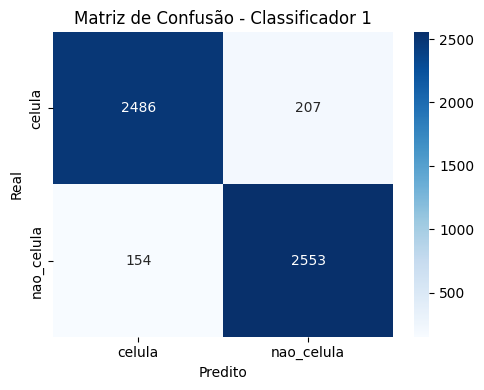

In [16]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=dataset.classes, yticklabels=dataset.classes, cmap="Blues")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("Matriz de Confusão - Classificador 1")
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, "results/c1/matriz_confusao.png"))
plt.show()
